### machine learning 

Data Successfully Loaded! Here are the first 5 rows:

   Revenue  Ads_Budget  Flyers_Distributed  Competitor_Price
0    50000        1000                 500              2500
1    52000        1200                 600              2450
2    55000        1500                 750              2600
3    60000        2000                1000              2400
4    62000        2200                1100              2550 



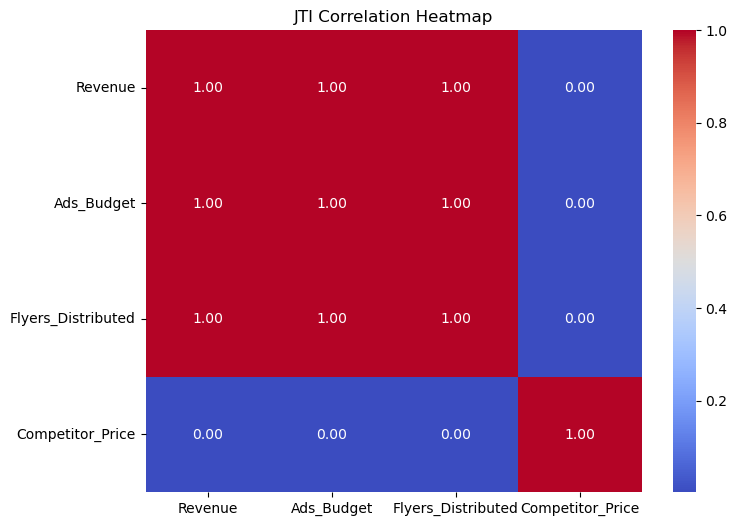

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- TERA JTI DATA (Generated inside Python) ---
data = {
    'Revenue': [50000, 52000, 55000, 60000, 62000, 65000, 68000, 70000, 71000, 75000, 
                76000, 80000, 82000, 85000, 88000, 90000, 92000, 95000, 98000, 100000],
    'Ads_Budget': [1000, 1200, 1500, 2000, 2200, 2500, 2800, 3000, 3100, 3500, 
                   3600, 4000, 4200, 4500, 4800, 5000, 5200, 5500, 5800, 6000],
    'Flyers_Distributed': [500, 600, 750, 1000, 1100, 1250, 1400, 1500, 1550, 1750, 
                           1800, 2000, 2100, 2250, 2400, 2500, 2600, 2750, 2900, 3000],
    'Competitor_Price': [2500, 2450, 2600, 2400, 2550, 2500, 2300, 2400, 2600, 2550, 
                         2450, 2350, 2650, 2500, 2400, 2550, 2450, 2600, 2500, 2400]
}

# Machine ko table format (DataFrame) mein de diya
jti_df = pd.DataFrame(data)
print("Data Successfully Loaded! Here are the first 5 rows:\n")
print(jti_df.head(), "\n")

# --- MISSION 1: HEATMAP (Pre-Flight Check) ---
plt.figure(figsize=(8,6))
sns.heatmap(jti_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("JTI Correlation Heatmap")
plt.show()

In [3]:
jti_df

,Revenue,Ads_Budget,Flyers_Distributed,Competitor_Price
0,50000,1000,500,2500
1,52000,1200,600,2450
2,55000,1500,750,2600
3,60000,2000,1000,2400
4,62000,2200,1100,2550
5,65000,2500,1250,2500
6,68000,2800,1400,2300
7,70000,3000,1500,2400
8,71000,3100,1550,2600
9,75000,3500,1750,2550


In [4]:
import statsmodels.formula.api as smf

# Model 1: Saare features daal diye (Kachra bhi, judwa bhai bhi)
model1 = smf.ols('Revenue ~ Ads_Budget + Flyers_Distributed + Competitor_Price', data=jti_df).fit()

# Scary Summary Table print kar
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.718e+22
Date:                Thu, 14 May 2026   Prob (F-statistic):          7.98e-182
Time:                        07:57:27   Log-Likelihood:                 269.80
No. Observations:                  20   AIC:                            -533.6
Df Residuals:                      17   BIC:                            -530.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept               4e+04   2.23

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- MISSION 3: VIF TEST (X-Ray) ---
X_features = jti_df[['Ads_Budget', 'Flyers_Distributed', 'Competitor_Price']]
vif_data = pd.DataFrame()
vif_data["Feature"] = X_features.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_features.values, i) for i in range(len(X_features.columns))]
print("--- VIF SCORES ---")
print(vif_data, "\n")

# --- MISSION 4: THE SURGERY (Flyers dropped) ---
# Naya model banate hain bina Flyers ke
model2 = smf.ols('Revenue ~ Ads_Budget + Competitor_Price', data=jti_df).fit()
print("--- NEW SURGERY SUMMARY ---")
print(model2.summary())

--- VIF SCORES ---
              Feature  VIF_Score
0          Ads_Budget        inf
1  Flyers_Distributed        inf
2    Competitor_Price   6.567394 

--- NEW SURGERY SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.921e+29
Date:                Thu, 14 May 2026   Prob (F-statistic):          2.27e-244
Time:                        08:18:05   Log-Likelihood:                 439.23
No. Observations:                  20   AIC:                            -872.5
Df Residuals:                      17   BIC:                            -869.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef  

C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


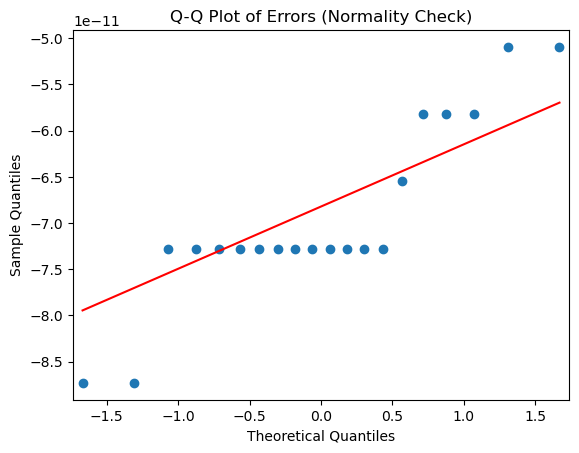

In [6]:
import statsmodels.api as sm

# Q-Q plot banayenge
fig = sm.qqplot(model2.resid, line='q')
plt.title("Q-Q Plot of Errors (Normality Check)")
plt.show()

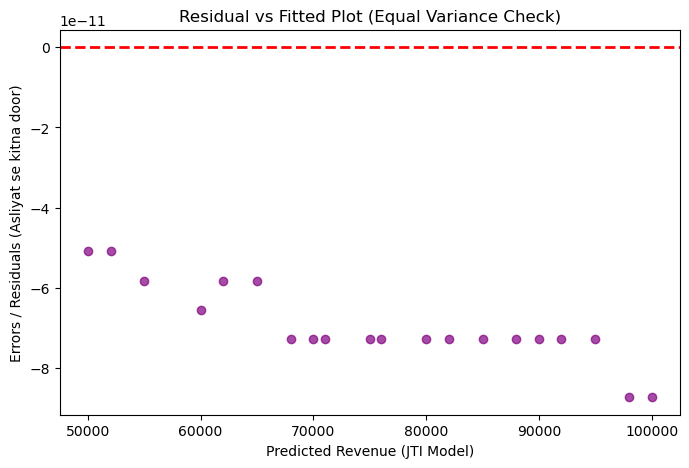

In [7]:
import matplotlib.pyplot as plt

# Fitted values (Prediction) vs Residuals (Galti) ka scatter plot
plt.figure(figsize=(8,5))
plt.scatter(model2.fittedvalues, model2.resid, color='purple', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=2) # Beech ki zero line
plt.xlabel("Predicted Revenue (JTI Model)")
plt.ylabel("Errors / Residuals (Asliyat se kitna door)")
plt.title("Residual vs Fitted Plot (Equal Variance Check)")
plt.show()

In [8]:
import pandas as pd

# Step 1: Aagle mahine ka input data ek table (DataFrame) mein daalo
future_data = pd.DataFrame({
    'Ads_Budget': [5000], 
    'Competitor_Price': [2400]
})

# Step 2: Naye Data ko apne Surgery wale Model mein predict karne ke liye daalo
predicted_revenue = model2.predict(future_data)

# Step 3: Result print karo!
print("=========================================")
print(f"👔 JTI CEO Sir, Next Month Estimated Revenue: ₹{predicted_revenue[0]:.2f}")
print("=========================================")

👔 JTI CEO Sir, Next Month Estimated Revenue: ₹90000.00
